# 02 SFT Review

Purpose: launch the Stage 1 QLoRA SFT run from the Drive-backed source tree, inspect the saved summary and curves, and review a few tuned sample outputs against the held-out eval rows.

Preconditions:
- Run `00_colab_setup.ipynb` first.
- Build the dataset manifests in Colab with `scripts/build_dataset_manifests.py --profile full` before starting training.


In [4]:
from pathlib import Path

SOURCE_ROOT = Path('/content/drive/MyDrive/json-ft-source')
RUNTIME_ROOT = Path('/content/drive/MyDrive/json-ft-runs')
PROFILE = 'full'
RUN_NAME = 'sft-full-colab'
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 32
TRAIN_SAMPLE_PERCENT = 0.10
EVAL_SAMPLE_PERCENT = 0.10
SAMPLE_SEED = 17

required_paths = [
    SOURCE_ROOT / 'scripts' / 'train_sft.py',
    SOURCE_ROOT / 'configs' / 'sft.yaml',
    SOURCE_ROOT / 'data' / 'manifests' / 'support_tickets_sft_messages.jsonl',
    SOURCE_ROOT / 'data' / 'manifests' / 'support_tickets_eval_manifest.jsonl',
    SOURCE_ROOT / 'data' / 'manifests' / 'support_tickets_dataset_build_summary.json',
    SOURCE_ROOT / 'artifacts' / 'metrics' / 'support_tickets_dataset_composition.json',
]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required SFT inputs:\n' + '\n'.join(str(path) for path in missing))

SOURCE_ROOT, RUNTIME_ROOT, PROFILE, RUN_NAME, TRAIN_BATCH_SIZE, EVAL_BATCH_SIZE, TRAIN_SAMPLE_PERCENT, EVAL_SAMPLE_PERCENT, SAMPLE_SEED


(PosixPath('/content/drive/MyDrive/json-ft-source'),
 PosixPath('/content/drive/MyDrive/json-ft-runs'),
 'full',
 'sft-full-colab',
 32,
 32,
 0.1,
 0.1,
 17)

In [5]:
!python /content/drive/MyDrive/json-ft-source/scripts/train_sft.py \
    --config /content/drive/MyDrive/json-ft-source/configs/sft.yaml \
    --profile {PROFILE} \
    --run-name {RUN_NAME} \
    --runtime-root /content/drive/MyDrive/json-ft-runs \
    --per-device-train-batch-size {TRAIN_BATCH_SIZE} \
    --per-device-eval-batch-size {EVAL_BATCH_SIZE} \
    --train-sample-percent {TRAIN_SAMPLE_PERCENT} \
    --eval-sample-percent {EVAL_SAMPLE_PERCENT} \
    --sample-seed {SAMPLE_SEED} \
    --mirror-metrics-to-repo \
    --mirror-plots-to-repo \
    --mirror-checkpoint-manifest-to-repo \
    --promote-latest


SFT training
Config: /content/drive/MyDrive/json-ft-source/configs/sft.yaml
Profile: full
Run name: sft-full-colab
Base model: Qwen/Qwen2.5-1.5B-Instruct
Train manifest: /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_sft_messages.jsonl
Eval manifest: /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_eval_manifest.jsonl
Dataset build summary: /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_dataset_build_summary.json
Dataset composition summary: /content/drive/MyDrive/json-ft-source/artifacts/metrics/support_tickets_dataset_composition.json
Train rows: 7116
Eval rows: 1245
Train subset: {'original_row_count': 71161, 'selected_row_count': 7116, 'selected_fraction': 0.0999985947358806, 'sample_mode': 'deterministic_percent', 'sample_seed': 17, 'sample_percent': 0.1, 'sample_limit': None, 'percent_row_count': 7116, 'absolute_limit_applied': False}
Eval subset: {'original_row_count': 12450, 'selected_row_count': 1245, 'selected_fr

In [6]:
import json

summary_path = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{RUN_NAME}_sft_summary.json'
summary = json.loads(summary_path.read_text(encoding='utf-8'))
summary


{'adapter_path': '/content/drive/MyDrive/json-ft-runs/persistent/checkpoints/sft/sft-full-colab/adapter',
 'base_model': 'Qwen/Qwen2.5-1.5B-Instruct',
 'checkpoint_root': '/content/drive/MyDrive/json-ft-runs/persistent/checkpoints/sft/sft-full-colab',
 'config_path': '/content/drive/MyDrive/json-ft-source/configs/sft.yaml',
 'data_pipeline': {'build_summary': {'leakage_checks': {'eval_root_count': 12450,
    'is_lineage_clean': True,
    'leaked_train_row_count': 0,
    'leaked_train_rows': []},
   'nullable_field_null_rates': {'customer.account_id': 1.0,
    'customer.name': 0.9714,
    'customer.plan_tier': 0.3018},
   'profile': 'full',
   'schema': {'name': 'support_ticket_extraction', 'version': '1.0.0'},
   'source_counts': {'console_ai_it_helpdesk_synthetic_tickets': 500,
    'prady06_customer_support_tickets': 61763,
    'synthetic_hardening_v1': 21341,
    'synthetic_support_tickets_v1': 7},
   'source_group_counts': {'domain_task_data': 62270,
    'synthetic_augmentation_data

loss_curve_path: /content/drive/MyDrive/json-ft-runs/persistent/plots/sft-full-colab_sft_loss_curve.png


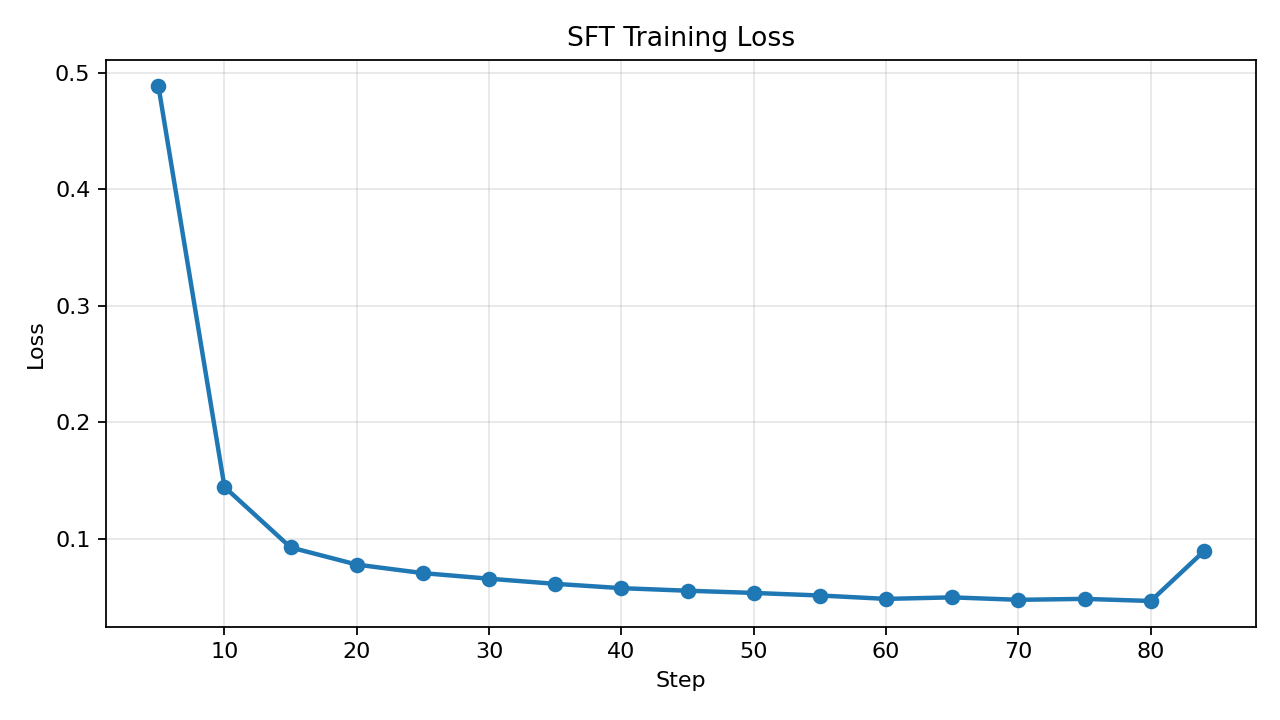

eval_loss_curve_path: /content/drive/MyDrive/json-ft-runs/persistent/plots/sft-full-colab_sft_eval_loss_curve.png


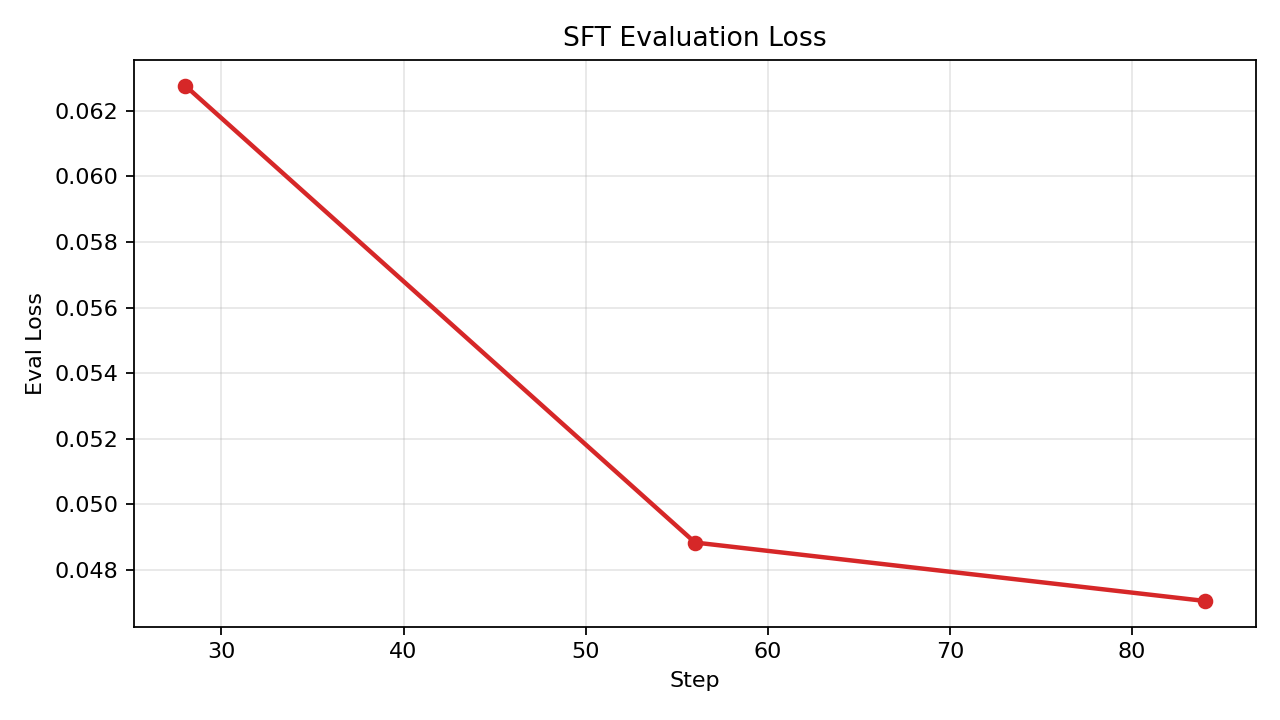

In [7]:
from IPython.display import Image, display

for key in ('loss_curve_path', 'eval_loss_curve_path'):
    curve_path = Path(summary.get(key, ''))
    if curve_path.exists():
        print(f'{key}: {curve_path}')
        display(Image(filename=str(curve_path)))
    else:
        print(f'{key}: not generated for this run')


In [8]:
import json
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

eval_manifest_path = SOURCE_ROOT / 'data' / 'manifests' / 'support_tickets_eval_manifest.jsonl'
eval_rows = [json.loads(line) for line in eval_manifest_path.read_text(encoding='utf-8').splitlines() if line.strip()]

compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)
tokenizer = AutoTokenizer.from_pretrained(summary['base_model'], trust_remote_code=False)
tokenizer.eos_token = '<|im_end|>'
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    summary['base_model'],
    quantization_config=quantization_config,
    torch_dtype=compute_dtype,
    device_map='auto',
    trust_remote_code=False,
)
model = PeftModel.from_pretrained(base_model, summary['adapter_path'])
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
for row in eval_rows[:3]:
    prompt_messages = row['messages'][:-1]
    encoded = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors='pt',
    )
    encoded = encoded.to(device)
    generated = model.generate(
        encoded,
        max_new_tokens=256,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    prediction_tokens = generated[0][encoded.shape[-1]:]
    prediction = tokenizer.decode(prediction_tokens, skip_special_tokens=True).strip()
    print(f"\n=== {row['record_id']} ===")
    print('PROMPT:')
    print(prompt_messages)
    print('\nTUNED OUTPUT:')
    print(prediction)
    print('\nREFERENCE JSON:')
    print(row['reference_json'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



=== 080jm0cxc ===
PROMPT:
[{'content': 'You are a structured support-ticket extraction assistant.\nReturn only valid JSON that follows the schema exactly.\nUse null for unknown customer fields.\nUse [] when the customer did not request any explicit action.\nDo not add keys that are not defined by the schema.\n\nSchema name: support_ticket_extraction\nSchema version: 1.0.0\nTop-level JSON object fields:\n- summary: string\n- issue_category: billing | account_access | technical_bug | feature_request | integration | general_question | other\n- priority: low | medium | high | urgent\n- product_area: web_app | mobile_app | api | billing_portal | account_portal | integrations | other | unknown\n- customer: object with fields name, account_id, plan_tier\n- customer.plan_tier: free | pro | business | enterprise | null\n- sentiment: negative | neutral | positive | mixed\n- requires_human_followup: boolean\n- actions_requested: list[string]', 'role': 'system'}, {'content': "Extract the support 